# Capstone – Gestión de Telecomunicaciones II  
## Proyecto 1: 5G FWA Rural (Escenario Base Uniforme)

Dataset y escenario numérico **uniforme** para todos los grupos.

**Archivos (carpeta `data/`):**
- `demand_points.csv` (puntos de demanda con hogares y suscriptores iniciales)
- `candidate_sites.csv` (sitios candidatos)
- `link_budget_matrices.npz` (dist_km, pathloss_db, rsrp_dbm)
- `scenario_params.json` (parámetros del escenario)

Incluye:
- Modelo simplificado de SINR (reuse-1) y capacidad
- Baseline de selección de sitios
- Plantilla de búsqueda local para Sprint 4


In [20]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data")
demand = pd.read_csv(DATA_DIR/"demand_points.csv")
sites = pd.read_csv(DATA_DIR/"candidate_sites.csv")
mat = np.load(DATA_DIR/"link_budget_matrices.npz")
dist_km = mat["dist_km"]
pathloss_db = mat["pathloss_db"]
rsrp_dbm = mat["rsrp_dbm"]
params = json.loads((DATA_DIR/"scenario_params.json").read_text())

print("Demand points:", len(demand))
print("Candidate sites:", len(sites))
print("RSRP matrix:", rsrp_dbm.shape)
demand.head()


Demand points: 220
Candidate sites: 36
RSRP matrix: (220, 36)


,dp_id,x_km,y_km,settlement_type,landclass,households,subscribers_initial
0,0,3.087773,3.081281,village,forest,14,4
1,1,4.950802,3.164556,village,forest,17,5
2,2,2.948100,5.386985,village,forest,15,4
3,3,4.610908,2.772241,village,rural,16,5
4,4,4.898507,3.167570,village,forest,12,4


In [21]:
BW_HZ = params["radio"]["bandwidth_mhz"]*1e6
NF_DB = params["radio"]["noise_figure_db"]
SE_CAP = 6.0

def dbm_to_w(dbm):
    return 10**((dbm-30)/10)

def thermal_noise_dbm(bw_hz, nf_db):
    return -174 + 10*np.log10(bw_hz) + nf_db

NOISE_DBM = thermal_noise_dbm(BW_HZ, NF_DB)
noise_w = dbm_to_w(NOISE_DBM)
print("Noise (dBm):", NOISE_DBM)


Noise (dBm): -90.97940008672037


In [22]:
def evaluate_plan(selected_sites, reuse1=True):
    sel = np.array(selected_sites, dtype=int)
    if len(sel)==0:
        return None

    rsrp_sel = rsrp_dbm[:, sel]  # [DP,S]
    best_local = np.argmax(rsrp_sel, axis=1)
    Pr_serv_dbm = rsrp_sel[np.arange(rsrp_sel.shape[0]), best_local]
    Pr_serv_w = dbm_to_w(Pr_serv_dbm)

    if reuse1 and len(sel)>1:
        Pr_all_w = dbm_to_w(rsrp_sel)
        interf_w = Pr_all_w.sum(axis=1) - Pr_serv_w
    else:
        interf_w = np.zeros_like(Pr_serv_w)

    sinr = Pr_serv_w / (interf_w + noise_w)
    sinr_db = 10*np.log10(sinr + 1e-12)

    se = np.log2(1+sinr)
    se = np.minimum(se, SE_CAP)
    cap_bps = BW_HZ * se

    subs = demand["subscribers_initial"].to_numpy()
    conc = params["demand"]["busy_hour_concurrency"]
    target_mbps = params["demand"]["target_throughput_mbps_per_subscriber"]
    demand_bps = subs * conc * target_mbps * 1e6

    satisfied = cap_bps >= demand_bps
    hh = demand["households"].to_numpy()

    pop_cov = float((hh*(cap_bps>0)).sum()/hh.sum())
    sat_frac = float((hh*satisfied).sum()/hh.sum())

    metrics = {
        "sites_deployed": int(len(sel)),
        "pop_covered_frac": pop_cov,
        "capacity_satisfied_frac": sat_frac,
        "avg_sinr_db": float(np.mean(sinr_db)),
        "p05_sinr_db": float(np.quantile(sinr_db, 0.05)),
        "avg_se_bphz": float(np.mean(se)),
    }
    return metrics

# Example
evaluate_plan([0,1,2,3,4])


{'sites_deployed': 5,
 'pop_covered_frac': 1.0,
 'capacity_satisfied_frac': 0.7,
 'avg_sinr_db': -0.9241236339574295,
 'p05_sinr_db': -24.123372383936776,
 'avg_se_bphz': 1.888568485986366}

In [23]:
def greedy_by_best_rsrp(S=8, thr_dbm=-95):
    score = (rsrp_dbm > thr_dbm).sum(axis=0)
    return list(np.argsort(-score)[:S])

def objective(m, w_cov=1.0, w_cap=1.0, w_sites=0.15):
    return w_cov*m["pop_covered_frac"] + w_cap*m["capacity_satisfied_frac"] - w_sites*(m["sites_deployed"]/params["planning"]["max_sites_to_deploy"])

def local_search(initial_sites, iters=400, S=8, seed=0):
    rng = np.random.default_rng(seed)
    all_sites = np.arange(len(sites))

    best = sorted(list(dict.fromkeys(initial_sites)))[:S]
    best_m = evaluate_plan(best)
    best_J = objective(best_m)

    for _ in range(iters):
        cand = best.copy()
        out = int(rng.integers(0, S))
        cand[out] = int(rng.choice(all_sites))
        cand = sorted(list(set(cand)))
        if len(cand)>S:
            cand = cand[:S]
        while len(cand)<S:
            cand.append(int(rng.choice(all_sites)))
            cand = sorted(list(set(cand)))
            if len(cand)>S:
                cand = cand[:S]

        m = evaluate_plan(cand)
        J = objective(m)
        if J > best_J:
            best, best_m, best_J = cand, m, J

    return best, best_m, best_J

init = greedy_by_best_rsrp(S=8)
best_sites, best_m, best_J = local_search(init, iters=600, S=8, seed=1)
print("Init:", init, evaluate_plan(init))
print("Best:", best_sites, best_m, best_J)


Init: [np.int64(3), np.int64(2), np.int64(0), np.int64(7), np.int64(4), np.int64(16), np.int64(6), np.int64(11)] {'sites_deployed': 8, 'pop_covered_frac': 1.0, 'capacity_satisfied_frac': 0.9583333333333334, 'avg_sinr_db': 6.540907965559194, 'p05_sinr_db': -10.555473930359346, 'avg_se_bphz': 2.5770324630941026}
Best: [np.int64(0), np.int64(3), np.int64(6), np.int64(7), 11, 12, 13, np.int64(16)] {'sites_deployed': 8, 'pop_covered_frac': 1.0, 'capacity_satisfied_frac': 0.9795833333333334, 'avg_sinr_db': 7.907271919742439, 'p05_sinr_db': -9.585938922523141, 'avg_se_bphz': 2.8853867959210295} 1.8795833333333332


# SPRINT 2 — MODELO TÉCNICO COMPLETO: SINR Y CAPACIDAD
## Objetivo del Sprint 2

En este sprint se revisa, implementa y valida de manera explícita el modelo técnico de la red 5G FWA.

La cadena de cálculo que se estudiará es:

**Sitios desplegados → Asociación por mejor RSRP → Interferencia + Ruido → SINR → Eficiencia espectral → Capacidad → Demanda Busy Hour → Cobertura y satisfacción de capacidad → Métricas**

El código original del notebook base se conserva sin modificaciones como referencia del Sprint 1.  
Las siguientes secciones corresponden al desarrollo y validación realizados por el equipo durante el Sprint 2.

---

## Asociación de cada punto de demanda por mejor RSRP

In [24]:
def associate_by_best_rsrp(selected_sites):
    """
    Asocia cada punto de demanda con el sitio desplegado
    que presenta el mayor RSRP.

    Parametros
    ----------
    selected_sites : lista
        Indices de los sitios que se consideran desplegados.

    Retorna
    -------
    rsrp_selected : matriz
        RSRP entre cada punto de demanda y los sitios desplegados.

    serving_site_local : vector
        Posicion del sitio servidor dentro de selected_sites.

    serving_site_global : vector
        Indice real del sitio servidor dentro de candidate_sites.csv.

    serving_rsrp_dbm : vector
        Mejor RSRP recibido por cada punto de demanda.
    """

    selected_sites = np.array(selected_sites, dtype=int)

    # Verificar que exista al menos un sitio desplegado
    if len(selected_sites) == 0:
        raise ValueError("Debe existir al menos un sitio desplegado.")

    # Extraer unicamente las columnas correspondientes
    # a los sitios que estan desplegados
    rsrp_selected = rsrp_dbm[:, selected_sites]

    # Para cada punto de demanda se busca el mayor RSRP.
    # El resultado indica la posicion dentro de selected_sites.
    serving_site_local = np.argmax(rsrp_selected, axis=1)

    # Convertir la posicion local al indice real del sitio candidato
    serving_site_global = selected_sites[serving_site_local]

    # Obtener el valor de RSRP correspondiente al sitio servidor
    serving_rsrp_dbm = rsrp_selected[
        np.arange(len(demand)),
        serving_site_local
    ]

    return (
        rsrp_selected,
        serving_site_local,
        serving_site_global,
        serving_rsrp_dbm
    )


# Evaluacion usando los mejores sitios obtenidos anteriormente
# en el notebook base

selected_sites_s2 = best_sites

(
    rsrp_selected_s2,
    serving_site_local_s2,
    serving_site_global_s2,
    serving_rsrp_dbm_s2
) = associate_by_best_rsrp(selected_sites_s2)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

# Debe existir una asociacion para cada punto de demanda
assert len(serving_site_global_s2) == len(demand)

# Todos los sitios servidores deben pertenecer al conjunto desplegado
assert set(np.unique(serving_site_global_s2)).issubset(
    set(selected_sites_s2)
)

# El RSRP servidor debe ser exactamente el maximo RSRP
# entre los sitios desplegados para cada punto
assert np.allclose(
    serving_rsrp_dbm_s2,
    np.max(rsrp_selected_s2, axis=1)
)

print("PB13 - Asociacion por mejor RSRP")
print("----------------------------------")
print("Sitios desplegados:", selected_sites_s2)
print("Puntos de demanda evaluados:", len(demand))
print("Todos los puntos tienen sitio servidor: OK")
print("Todos los sitios servidores pertenecen al plan desplegado: OK")
print("El RSRP servidor corresponde al maximo disponible: OK")


# Mostrar algunos resultados
association_results = pd.DataFrame({
    "demand_point": np.arange(len(demand)),
    "serving_site": serving_site_global_s2,
    "serving_rsrp_dbm": serving_rsrp_dbm_s2
})

association_results.head(10)

PB13 - Asociacion por mejor RSRP
----------------------------------
Sitios desplegados: [np.int64(0), np.int64(3), np.int64(6), np.int64(7), 11, 12, 13, np.int64(16)]
Puntos de demanda evaluados: 220
Todos los puntos tienen sitio servidor: OK
Todos los sitios servidores pertenecen al plan desplegado: OK
El RSRP servidor corresponde al maximo disponible: OK


,demand_point,serving_site,serving_rsrp_dbm
0,0,0,-75.471771
1,1,3,-67.153893
2,2,16,-91.421471
3,3,3,-72.603554
4,4,3,-70.460770
5,5,3,-80.579575
6,6,3,-85.704315
7,7,3,-84.480751
8,8,3,-65.780739
9,9,3,-76.025604


## Cálculo de interferencia reuse-1

In [25]:
def calculate_reuse1_interference(rsrp_selected, serving_rsrp_dbm):
    """
    Calcula la interferencia total recibida por cada punto
    de demanda bajo un esquema frequency reuse-1.

    Parámetros
    ----------
    rsrp_selected : matriz
        RSRP de cada punto de demanda respecto a los sitios desplegados.

    serving_rsrp_dbm : vector
        RSRP correspondiente al sitio servidor de cada punto.

    Retorna
    -------
    received_power_all_w : matriz
        Potencias recibidas desde todos los sitios desplegados,
        expresadas en watts.

    serving_power_w : vector
        Potencia recibida desde el sitio servidor, en watts.

    interference_w : vector
        Interferencia total recibida por cada punto, en watts.
    """

    # Convertir todas las potencias recibidas de dBm a watts
    received_power_all_w = dbm_to_w(rsrp_selected)

    # Convertir la potencia del sitio servidor de dBm a watts
    serving_power_w = dbm_to_w(serving_rsrp_dbm)

    # Sumar la potencia recibida desde todos los sitios desplegados
    total_received_power_w = np.sum(
        received_power_all_w,
        axis=1
    )

    # La interferencia es la potencia total menos la potencia servidora
    interference_w = (
        total_received_power_w
        - serving_power_w
    )

    return (
        received_power_all_w,
        serving_power_w,
        interference_w
    )


# ------------------------------------------------------------
# Calcular interferencia para el escenario obtenido en PB13
# ------------------------------------------------------------

(
    received_power_all_w_s2,
    serving_power_w_s2,
    interference_w_s2
) = calculate_reuse1_interference(
    rsrp_selected_s2,
    serving_rsrp_dbm_s2
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

# Debe existir un valor de interferencia por cada punto de demanda
assert len(interference_w_s2) == len(demand)

# La interferencia no puede ser negativa
assert np.all(interference_w_s2 >= -1e-15)

# Verificar que:
# potencia servidora + interferencia = potencia total recibida
assert np.allclose(
    serving_power_w_s2 + interference_w_s2,
    np.sum(received_power_all_w_s2, axis=1)
)

print("PB14 — Interferencia reuse-1")
print("----------------------------------")
print("Puntos de demanda evaluados:", len(demand))
print("Interferencia calculada para todos los puntos: OK")
print("La interferencia es no negativa: OK")
print("La potencia servidora fue excluida correctamente: OK")


# ------------------------------------------------------------
# Mostrar algunos resultados
# ------------------------------------------------------------

interference_results = pd.DataFrame({
    "demand_point": np.arange(len(demand)),
    "serving_site": serving_site_global_s2,
    "serving_rsrp_dbm": serving_rsrp_dbm_s2,
    "serving_power_w": serving_power_w_s2,
    "interference_w": interference_w_s2
})

interference_results.head(10)

PB14 — Interferencia reuse-1
----------------------------------
Puntos de demanda evaluados: 220
Interferencia calculada para todos los puntos: OK
La interferencia es no negativa: OK
La potencia servidora fue excluida correctamente: OK


,demand_point,serving_site,serving_rsrp_dbm,serving_power_w,interference_w
0,0,0,-75.471771,2.836761e-11,1.713305e-12
1,1,3,-67.153893,1.925798e-10,3.913064e-12
2,2,16,-91.421471,7.208633e-13,1.038675e-13
3,3,3,-72.603554,5.490918e-11,5.451837e-12
4,4,3,-70.460770,8.993386e-11,4.583584e-12
5,5,3,-80.579575,8.750691e-12,2.229999e-12
6,6,3,-85.704315,2.688861e-12,1.186722e-12
7,7,3,-84.480751,3.563893e-12,8.147916e-13
8,8,3,-65.780739,2.641962e-10,1.180307e-10
9,9,3,-76.025604,2.497123e-11,6.557326e-12


## Cálculo y validación del SINR por punto de demanda

In [26]:
def calculate_sinr(
    serving_power_w,
    interference_w,
    noise_power_w
):
    """
    Calcula el SINR de cada punto de demanda.

    Parámetros
    ----------
    serving_power_w : vector
        Potencia recibida desde el sitio servidor, en watts.

    interference_w : vector
        Interferencia total recibida desde los demás sitios,
        en watts.

    noise_power_w : float
        Potencia de ruido térmico, en watts.

    Retorna
    -------
    sinr_linear : vector
        SINR en escala lineal.

    sinr_db : vector
        SINR expresado en dB.
    """

    # SINR en escala lineal
    sinr_linear = serving_power_w / (
        interference_w + noise_power_w
    )

    # Conversión a dB
    sinr_db = 10 * np.log10(
        sinr_linear + 1e-12
    )

    return sinr_linear, sinr_db


# ------------------------------------------------------------
# Calcular SINR para los 220 puntos
# ------------------------------------------------------------

sinr_linear_s2, sinr_db_s2 = calculate_sinr(
    serving_power_w_s2,
    interference_w_s2,
    noise_w
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

# Debe existir un SINR por cada punto de demanda
assert len(sinr_db_s2) == len(demand)

# El SINR lineal debe ser positivo
assert np.all(sinr_linear_s2 > 0)

# Todos los resultados deben ser valores finitos
assert np.all(np.isfinite(sinr_linear_s2))
assert np.all(np.isfinite(sinr_db_s2))


# ------------------------------------------------------------
# Métricas básicas de SINR
# ------------------------------------------------------------

avg_sinr_db_s2 = np.mean(sinr_db_s2)
p05_sinr_db_s2 = np.quantile(sinr_db_s2, 0.05)


# Comparar con el resultado del baseline
baseline_metrics_s2 = evaluate_plan(selected_sites_s2)

assert np.isclose(
    avg_sinr_db_s2,
    baseline_metrics_s2["avg_sinr_db"]
)

assert np.isclose(
    p05_sinr_db_s2,
    baseline_metrics_s2["p05_sinr_db"]
)


print("PB15 — Cálculo de SINR")
print("----------------------------------")
print("Puntos de demanda evaluados:", len(demand))
print("SINR calculado para todos los puntos: OK")
print("Todos los SINR lineales son positivos: OK")
print("Todos los valores son finitos: OK")
print("Coincidencia con métricas del baseline: OK")
print()

print("SINR promedio:", avg_sinr_db_s2, "dB")
print("Percentil 5 del SINR:", p05_sinr_db_s2, "dB")


# ------------------------------------------------------------
# Mostrar algunos resultados
# ------------------------------------------------------------

sinr_results = pd.DataFrame({
    "demand_point": np.arange(len(demand)),
    "serving_site": serving_site_global_s2,
    "serving_rsrp_dbm": serving_rsrp_dbm_s2,
    "interference_w": interference_w_s2,
    "sinr_linear": sinr_linear_s2,
    "sinr_db": sinr_db_s2
})

sinr_results.head(10)

PB15 — Cálculo de SINR
----------------------------------
Puntos de demanda evaluados: 220
SINR calculado para todos los puntos: OK
Todos los SINR lineales son positivos: OK
Todos los valores son finitos: OK
Coincidencia con métricas del baseline: OK

SINR promedio: 7.907271919742439 dB
Percentil 5 del SINR: -9.585938922523141 dB


,demand_point,serving_site,serving_rsrp_dbm,interference_w,sinr_linear,sinr_db
0,0,0,-75.471771,1.713305e-12,11.295490,10.529051
1,1,3,-67.153893,3.913064e-12,40.877286,16.114821
2,2,16,-91.421471,1.038675e-13,0.799208,-0.973403
3,3,3,-72.603554,5.451837e-12,8.785551,9.437690
4,4,3,-70.460770,4.583584e-12,16.711086,12.230047
5,5,3,-80.579575,2.229999e-12,2.889825,4.608716
6,6,3,-85.704315,1.186722e-12,1.354708,1.318457
7,7,3,-84.480751,8.147916e-13,2.209623,3.443182
8,8,3,-65.780739,1.180307e-10,2.223334,3.470047
9,9,3,-76.025604,6.557326e-12,3.394938,5.308319


## Conversión de SINR a eficiencia espectral

In [27]:
# ============================================================
# SOLUCIÓN PB17 — CÁLCULO Y VALIDACIÓN
# ============================================================

# 1. Calcular eficiencia espectral acotada al límite SE_CAP
se_bphz_s2 = np.minimum(np.log2(1 + sinr_linear_s2), SE_CAP)

# ------------------------------------------------------------
# VALIDACIONES MÍNIMAS (Sanity Checks)
# ------------------------------------------------------------

# 1. Deben existir 220 valores (mismo tamaño que el SINR)
assert len(se_bphz_s2) == len(sinr_linear_s2), "El vector no tiene 220 valores"

# 2. Todos los valores deben ser >= 0
assert np.all(se_bphz_s2 >= 0), "Hay valores de eficiencia espectral negativos"

# 3. Ningún valor debe superar SE_CAP = 6 bps/Hz
assert np.all(se_bphz_s2 <= SE_CAP), "Hay valores que superan el límite SE_CAP"

# 4. Calcular el promedio de se_bphz_s2
avg_se_bphz = np.mean(se_bphz_s2)

# 5. Comparar dicho promedio con el reportado en el baseline
# Usamos np.isclose para evitar errores estrictos de redondeo de decimales
assert np.isclose(avg_se_bphz, baseline_metrics_s2["avg_se_bphz"]), "El cálculo difiere del baseline"

print("PB17 — Cálculo de Eficiencia Espectral")
print("--------------------------------------")
print("Eficiencia espectral calculada para todos los puntos: OK")
print("Límites de valores (>=0 y <=6): OK")
print("Coincidencia con métricas del baseline: OK")
print()
print(f"Eficiencia espectral promedio: {avg_se_bphz:.4f} bps/Hz")

PB17 — Cálculo de Eficiencia Espectral
--------------------------------------
Eficiencia espectral calculada para todos los puntos: OK
Límites de valores (>=0 y <=6): OK
Coincidencia con métricas del baseline: OK

Eficiencia espectral promedio: 2.8854 bps/Hz


## Demanda Busy Hour por punto

In [28]:
# ============================================================
# SOLUCIÓN PB19 — Demanda Busy Hour
# ============================================================

# 1. Extraer las variables de los diccionarios y dataframes
subs = demand["subscribers_initial"].to_numpy()
conc = params["demand"]["busy_hour_concurrency"]
target_mbps = params["demand"]["target_throughput_mbps_per_subscriber"]

# 2. Calcular la demanda total en bps (multiplicando por 1e6)
demand_bps_s2 = subs * conc * target_mbps * 1e6

# ------------------------------------------------------------
# VALIDACIONES MÍNIMAS (Sanity Checks)
# ------------------------------------------------------------

# 1. Deben existir 220 valores
assert len(demand_bps_s2) == len(demand), "Error: No hay 220 valores"

# 2. Todos los valores deben ser >= 0
assert np.all(demand_bps_s2 >= 0), "Error: Hay valores de demanda negativos"

print("PB19 — Cálculo de Demanda Busy Hour")
print("--------------------------------------")
print("Demanda calculada para todos los puntos: OK")
print("Límites de valores (>=0): OK")
print()
# Mostrar los primeros 5 resultados como verificación manual
print("Muestra de demanda para los primeros 5 puntos (bps):")
print(demand_bps_s2[:5])

PB19 — Cálculo de Demanda Busy Hour
--------------------------------------
Demanda calculada para todos los puntos: OK
Límites de valores (>=0): OK

Muestra de demanda para los primeros 5 puntos (bps):
[16000000. 20000000. 16000000. 20000000. 16000000.]


## Capacidad y satisfacción de demanda por punto

In [29]:
# ============================================================
# SOLUCIÓN PB18 — Capacidad y satisfacción de demanda por punto
# ============================================================

# OBJETIVO 1 — Calcular capacidad total (bps)
cap_bps_s2 = BW_HZ * se_bphz_s2

# OBJETIVO 2 — Comparar capacidad contra demanda (Máscara booleana)
satisfied_mask_s2 = cap_bps_s2 >= demand_bps_s2

# ------------------------------------------------------------
# VALIDACIONES MÍNIMAS (Sanity Checks)
# ------------------------------------------------------------

# 1 y 2. Validar tamaño y que no haya capacidades negativas
assert len(cap_bps_s2) == len(demand), "Error: cap_bps_s2 no tiene 220 valores"
assert np.all(cap_bps_s2 >= 0), "Error: Hay capacidades calculadas negativas"

# 3 y 4. Validar máscara booleana
assert satisfied_mask_s2.dtype == bool, "Error: satisfied_mask_s2 no es tipo booleano"
assert len(satisfied_mask_s2) == len(demand), "Error: La máscara no tiene 220 valores"

# 5. Comparar el resultado agregado contra el baseline
# Extraemos los hogares como se hizo originalmente en evaluate_plan()
hh = demand["households"].to_numpy()

# Calculamos la fracción de capacidad satisfecha ponderada por hogares
capacity_satisfied_frac = float((hh * satisfied_mask_s2).sum() / hh.sum())

# Comparamos con las métricas del baseline (usamos np.isclose por los decimales)
assert np.isclose(capacity_satisfied_frac, baseline_metrics_s2["capacity_satisfied_frac"]), "Error: El porcentaje difiere del baseline"

print("PB18 — Capacidad y Satisfacción")
print("--------------------------------------")
print("Capacidad calculada (>=0 y 220 valores): OK")
print("Máscara de satisfacción (Booleana y 220 valores): OK")
print("Coincidencia con metrics del baseline: OK")
print()
print(f"Fracción de capacidad satisfecha general: {capacity_satisfied_frac:.4f} ({(capacity_satisfied_frac*100):.1f}%)")

PB18 — Capacidad y Satisfacción
--------------------------------------
Capacidad calculada (>=0 y 220 valores): OK
Máscara de satisfacción (Booleana y 220 valores): OK
Coincidencia con metrics del baseline: OK

Fracción de capacidad satisfecha general: 0.9796 (98.0%)


## Criterio de cobertura y comparación baseline

In [30]:
# ------------------------------------------------------------
# PB20 — Definir formalmente el criterio de cobertura
# ------------------------------------------------------------

# El scenario_params.json define un umbral mínimo de SINR
# para considerar que un punto se encuentra cubierto.
coverage_threshold_db_s2 = (
    params["radio"]["sinr_thresholds_db"]["coverage_min_sinr_db"]
)

# Un punto se considera cubierto cuando su SINR es mayor
# o igual al umbral definido en el JSON.
coverage_mask_s2 = sinr_db_s2 >= coverage_threshold_db_s2

# Número de puntos cubiertos
covered_points_s2 = np.sum(coverage_mask_s2)

# Hogares representados por cada punto de demanda
households_s2 = demand["households"].to_numpy()

# Total de hogares del escenario
total_households_s2 = households_s2.sum()

# Hogares ubicados en puntos que cumplen el umbral de cobertura
covered_households_s2 = households_s2[coverage_mask_s2].sum()

# Cobertura poblacional ponderada por hogares
pop_covered_frac_s2 = (
    covered_households_s2 / total_households_s2
)


# ------------------------------------------------------------
# PB21 — Comparación contra el criterio usado en el baseline
# ------------------------------------------------------------

# El baseline define cobertura mediante:
#
#       cap_bps > 0
#
# Para reproducir exactamente ese criterio utilizamos las mismas
# ecuaciones de eficiencia espectral y capacidad del baseline.

se_baseline_check_s2 = np.log2(1 + sinr_linear_s2)
se_baseline_check_s2 = np.minimum(
    se_baseline_check_s2,
    SE_CAP
)

cap_baseline_check_s2 = BW_HZ * se_baseline_check_s2

# Máscara de cobertura utilizada en el baseline
coverage_mask_baseline_s2 = cap_baseline_check_s2 > 0

# Cobertura poblacional según el criterio del baseline
pop_covered_frac_baseline_s2 = (
    households_s2[coverage_mask_baseline_s2].sum()
    / total_households_s2
)


# ------------------------------------------------------------
# Identificar los puntos que NO cumplen el criterio de SINR
# ------------------------------------------------------------

not_covered_points_s2 = np.where(~coverage_mask_s2)[0]

not_covered_households_s2 = (
    households_s2[~coverage_mask_s2].sum()
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

# Debe existir una decisión de cobertura por cada punto
assert len(coverage_mask_s2) == len(demand)

# La cobertura debe estar entre 0 y 1
assert 0 <= pop_covered_frac_s2 <= 1
assert 0 <= pop_covered_frac_baseline_s2 <= 1

# El total ponderado debe coincidir con el total de hogares
assert (
    covered_households_s2
    + not_covered_households_s2
    == total_households_s2
)

# El resultado calculado con el criterio del baseline debe coincidir
# con la métrica reportada originalmente por evaluate_plan()
baseline_metrics_pb21 = evaluate_plan(selected_sites_s2)

assert np.isclose(
    pop_covered_frac_baseline_s2,
    baseline_metrics_pb21["pop_covered_frac"]
)


# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------

print(" Cobertura poblacional")
print("----------------------------------------------")

print("Umbral de cobertura definido en JSON:",
      coverage_threshold_db_s2, "dB")

print()
print("CRITERIO FORMAL DEL SPRINT 2")
print("----------------------------------------------")
print("Puntos cubiertos:",
      covered_points_s2, "/", len(demand))

print("Puntos no cubiertos:",
      len(not_covered_points_s2), "/", len(demand))

print("Hogares cubiertos:",
      covered_households_s2, "/", total_households_s2)

print("Hogares no cubiertos:",
      not_covered_households_s2)

print("Cobertura poblacional:",
      f"{pop_covered_frac_s2:.4f}",
      f"({pop_covered_frac_s2*100:.2f} %)")

print()
print("CRITERIO UTILIZADO POR EL BASELINE")
print("----------------------------------------------")

print("Cobertura baseline (cap_bps > 0):",
      f"{pop_covered_frac_baseline_s2:.4f}",
      f"({pop_covered_frac_baseline_s2*100:.2f} %)")

print()
print("DIFERENCIA ENTRE CRITERIOS")
print("----------------------------------------------")

difference_coverage_s2 = (
    pop_covered_frac_baseline_s2
    - pop_covered_frac_s2
)

print("Diferencia:",
      f"{difference_coverage_s2:.4f}",
      f"({difference_coverage_s2*100:.2f} puntos porcentuales)")

print()
print("Puntos que no cumplen SINR >=", coverage_threshold_db_s2, "dB:")
print(not_covered_points_s2)


# ------------------------------------------------------------
# Tabla de puntos no cubiertos
# ------------------------------------------------------------

not_covered_results_s2 = pd.DataFrame({
    "demand_point": not_covered_points_s2,
    "households": demand.loc[
        not_covered_points_s2,
        "households"
    ].to_numpy(),
    "serving_site": serving_site_global_s2[
        not_covered_points_s2
    ],
    "serving_rsrp_dbm": serving_rsrp_dbm_s2[
        not_covered_points_s2
    ],
    "sinr_db": sinr_db_s2[
        not_covered_points_s2
    ]
})

not_covered_results_s2

 Cobertura poblacional
----------------------------------------------
Umbral de cobertura definido en JSON: -3.0 dB

CRITERIO FORMAL DEL SPRINT 2
----------------------------------------------
Puntos cubiertos: 198 / 220
Puntos no cubiertos: 22 / 220
Hogares cubiertos: 2300 / 2400
Hogares no cubiertos: 100
Cobertura poblacional: 0.9583 (95.83 %)

CRITERIO UTILIZADO POR EL BASELINE
----------------------------------------------
Cobertura baseline (cap_bps > 0): 1.0000 (100.00 %)

DIFERENCIA ENTRE CRITERIOS
----------------------------------------------
Diferencia: 0.0417 (4.17 puntos porcentuales)

Puntos que no cumplen SINR >= -3.0 dB:
[116 171 173 175 176 178 179 183 188 190 192 198 204 206 208 209 210 211
 212 214 215 219]


,demand_point,households,serving_site,serving_rsrp_dbm,sinr_db
0,116,15,7,-99.258507,-8.470938
1,171,6,13,-99.983559,-10.114977
2,173,6,0,-96.458549,-6.764797
3,175,4,6,-99.857964,-9.561555
4,176,3,13,-96.877159,-6.468087
5,178,6,16,-94.096756,-3.667595
6,179,7,3,-95.210762,-4.942649
7,183,7,13,-110.067001,-19.195044
8,188,4,11,-102.307098,-11.370013
9,190,6,11,-105.501518,-14.641828


## Implementación y verificación de métricas técnicas

In [31]:
# ============================================================
# PB22 — Implementación y verificación de métricas técnicas
# ============================================================

households_pb22 = demand["households"].to_numpy()
total_households_pb22 = households_pb22.sum()

# 1. Cobertura poblacional (criterio corregido PB20: SINR >= coverage_min_sinr_db)
pop_covered_frac_pb22 = float(pop_covered_frac_s2)

# 2. Fracción de capacidad satisfecha, ponderada por hogares
capacity_satisfied_frac_pb22 = float(
    (households_pb22 * satisfied_mask_s2).sum() / total_households_pb22
)

# 3-5. Métricas de radio
avg_sinr_db_pb22 = float(np.mean(sinr_db_s2))
p05_sinr_db_pb22 = float(np.quantile(sinr_db_s2, 0.05))
avg_se_bphz_pb22 = float(np.mean(se_bphz_s2))

# 6. Sitios desplegados
sites_deployed_pb22 = int(len(selected_sites_s2))

metrics_sprint2 = {
    "sites_deployed": sites_deployed_pb22,
    "pop_covered_frac": pop_covered_frac_pb22,
    "capacity_satisfied_frac": capacity_satisfied_frac_pb22,
    "avg_sinr_db": avg_sinr_db_pb22,
    "p05_sinr_db": p05_sinr_db_pb22,
    "avg_se_bphz": avg_se_bphz_pb22,
}

# ------------------------------------------------------------
# Validaciones mínimas
# ------------------------------------------------------------
assert 0.0 <= metrics_sprint2["pop_covered_frac"] <= 1.0
assert 0.0 <= metrics_sprint2["capacity_satisfied_frac"] <= 1.0
assert metrics_sprint2["sites_deployed"] <= params["planning"]["max_sites_to_deploy"]
assert all(np.isfinite(v) for v in metrics_sprint2.values())

# La cobertura NO debe coincidir con el criterio cap_bps > 0 del baseline
# salvo que todos los puntos superen el umbral de SINR.
baseline_metrics_pb22 = evaluate_plan(selected_sites_s2)

print("PB22 — Métricas técnicas del Sprint 2")
print("--------------------------------------------------")
for k, v in metrics_sprint2.items():
    print(f"{k:>26}: {v}")

print()
print("Comparación con el baseline")
print("--------------------------------------------------")
for k in metrics_sprint2:
    b = baseline_metrics_pb22[k]
    m = metrics_sprint2[k]
    igual = "OK (coincide)" if np.isclose(b, m) else "DIFIERE"
    print(f"{k:>26}: baseline={b:>10.4f} | sprint2={m:>10.4f}  {igual}")

print()
print("Nota: pop_covered_frac difiere porque el baseline usa cap_bps > 0")
print("y el Sprint 2 usa SINR >=", coverage_threshold_db_s2, "dB (PB20/PB21).")

PB22 — Métricas técnicas del Sprint 2
--------------------------------------------------
            sites_deployed: 8
          pop_covered_frac: 0.9583333333333334
   capacity_satisfied_frac: 0.9795833333333334
               avg_sinr_db: 7.907271919742439
               p05_sinr_db: -9.585938922523141
               avg_se_bphz: 2.8853867959210295

Comparación con el baseline
--------------------------------------------------
            sites_deployed: baseline=    8.0000 | sprint2=    8.0000  OK (coincide)
          pop_covered_frac: baseline=    1.0000 | sprint2=    0.9583  DIFIERE
   capacity_satisfied_frac: baseline=    0.9796 | sprint2=    0.9796  OK (coincide)
               avg_sinr_db: baseline=    7.9073 | sprint2=    7.9073  OK (coincide)
               p05_sinr_db: baseline=   -9.5859 | sprint2=   -9.5859  OK (coincide)
               avg_se_bphz: baseline=    2.8854 | sprint2=    2.8854  OK (coincide)

Nota: pop_covered_frac difiere porque el baseline usa cap_bps > 0
y 

## Pruebas y sanity checks del modelo técnico completo

In [32]:
# ============================================================
# SOLUCIÓN PB23 — Pruebas y sanity checks del modelo técnico
# ============================================================

print("Iniciando pruebas de cordura (Sanity Checks)...\n")

# 1. Dimensiones (Deben existir 220 resultados por variable)
N = len(demand)
assert len(serving_site_global_s2) == N
assert len(serving_rsrp_dbm_s2) == N
assert len(interference_w_s2) == N
assert len(sinr_linear_s2) == N
assert len(sinr_db_s2) == N
assert len(se_bphz_s2) == N
assert len(demand_bps_s2) == N
assert len(cap_bps_s2) == N
assert len(coverage_mask_s2) == N
assert len(satisfied_mask_s2) == N
print("1. Dimensiones de vectores correctas (220 valores): OK")

# 2. Sitios servidores deben pertenecer a selected_sites_s2
assert set(serving_site_global_s2).issubset(set(selected_sites_s2))
print("2. Pertenencia de sitios servidores validada: OK")

# 3. interference_w_s2 >= 0
assert np.all(interference_w_s2 >= 0)
print("3. Valores de interferencia >= 0: OK")

# 4. sinr_linear_s2 > 0
assert np.all(sinr_linear_s2 > 0)
print("4. Valores de SINR lineal > 0: OK")

# 5. Valores finitos en sinr_db_s2
assert np.all(np.isfinite(sinr_db_s2))
print("5. Valores de SINR en dB son finitos: OK")

# 6. se_bphz_s2 debe cumplir 0 <= SE <= 6 (SE_CAP)
assert np.all((se_bphz_s2 >= 0) & (se_bphz_s2 <= SE_CAP))
print("6. Eficiencia espectral dentro de los límites: OK")

# 7 y 8. Demandas y capacidades >= 0
assert np.all(demand_bps_s2 >= 0)
assert np.all(cap_bps_s2 >= 0)
print("7 y 8. Capacidades y demandas calculadas >= 0: OK")

# 9 y 10. Máscaras de tipo booleano (True/False)
assert coverage_mask_s2.dtype == bool
assert satisfied_mask_s2.dtype == bool
print("9 y 10. Máscaras convertidas correctamente a booleanos: OK")

# 11. Fracciones finales del Sprint 2 entre 0 y 1
# Se validan las métricas finales corregidas, no las del baseline.
cov_frac = metrics_sprint2["pop_covered_frac"]
cap_frac = metrics_sprint2["capacity_satisfied_frac"]
assert 0.0 <= cov_frac <= 1.0
assert 0.0 <= cap_frac <= 1.0
print("11. Fracciones finales del Sprint 2 acotadas [0,1]: OK")

# 12. Sitios desplegados respeta el máximo permitido
max_sites = params["planning"]["max_sites_to_deploy"]
assert len(selected_sites_s2) <= max_sites
print("12. Regla de negocio (max sitios desplegados) cumplida: OK\n")

# ------------------------------------------------------------
# PRUEBA ESPECIAL RECOMENDADA (Inspección manual punto 0)
# ------------------------------------------------------------
pto = 0
print(f"--- Trazabilidad de la red para el Punto de Demanda {pto} ---")
print(f"Señal (RSRP servidor): {serving_rsrp_dbm_s2[pto]:.2f} dBm")
print(f"Interferencia (W):     {interference_w_s2[pto]:.3e} Watts")
print(f"SINR calculado (dB):   {sinr_db_s2[pto]:.2f} dB")
print(f"Eficiencia espectral:  {se_bphz_s2[pto]:.2f} bps/Hz")
print(f"Capacidad entregada:   {cap_bps_s2[pto]/1e6:.2f} Mbps")
print(f"Demanda exigida:       {demand_bps_s2[pto]/1e6:.2f} Mbps")
print(f"¿Cliente satisfecho?:  {'Sí (True)' if satisfied_mask_s2[pto] else 'No (False)'}")
print("============================================================\n")
print("¡TODOS LOS SANITY CHECKS DEL MODELO TÉCNICO PASARON CON ÉXITO!")



Iniciando pruebas de cordura (Sanity Checks)...

1. Dimensiones de vectores correctas (220 valores): OK
2. Pertenencia de sitios servidores validada: OK
3. Valores de interferencia >= 0: OK
4. Valores de SINR lineal > 0: OK
5. Valores de SINR en dB son finitos: OK
6. Eficiencia espectral dentro de los límites: OK
7 y 8. Capacidades y demandas calculadas >= 0: OK
9 y 10. Máscaras convertidas correctamente a booleanos: OK
11. Fracciones finales del Sprint 2 acotadas [0,1]: OK
12. Regla de negocio (max sitios desplegados) cumplida: OK

--- Trazabilidad de la red para el Punto de Demanda 0 ---
Señal (RSRP servidor): -75.47 dBm
Interferencia (W):     1.713e-12 Watts
SINR calculado (dB):   10.53 dB
Eficiencia espectral:  3.62 bps/Hz
Capacidad entregada:   144.80 Mbps
Demanda exigida:       16.00 Mbps
¿Cliente satisfecho?:  Sí (True)

¡TODOS LOS SANITY CHECKS DEL MODELO TÉCNICO PASARON CON ÉXITO!


## Visualización de puntos de demanda y sitios candidatos

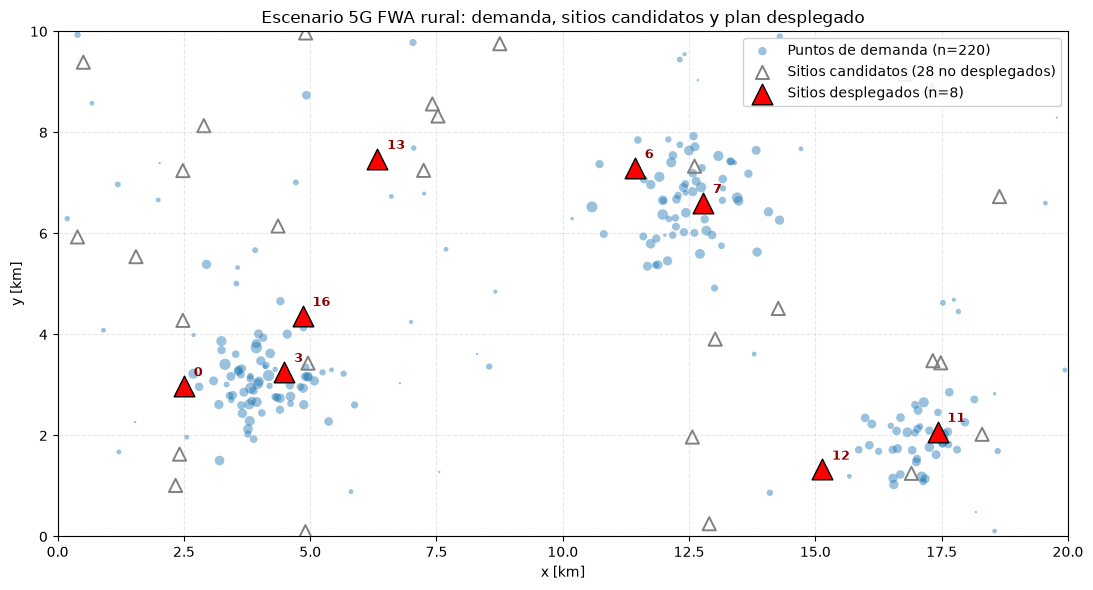

PB24 — Visualización del escenario
Puntos de demanda: 220
Sitios candidatos: 36
Sitios desplegados: [np.int64(0), np.int64(3), np.int64(6), np.int64(7), np.int64(11), np.int64(12), np.int64(13), np.int64(16)]


In [33]:
# ============================================================
# PB24 — Visualización de puntos de demanda y sitios candidatos
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

selected_pb24 = np.array(selected_sites_s2, dtype=int)
mask_desplegado = sites.index.isin(selected_pb24)

fig, ax = plt.subplots(figsize=(12, 6))

# Puntos de demanda (tamaño proporcional a hogares)
ax.scatter(
    demand["x_km"], demand["y_km"],
    s=demand["households"] * 3,
    c="tab:blue", alpha=0.45, edgecolors="none",
    label=f"Puntos de demanda (n={len(demand)})",
)

# Sitios candidatos no desplegados
ax.scatter(
    sites.loc[~mask_desplegado, "x_km"], sites.loc[~mask_desplegado, "y_km"],
    marker="^", s=90, facecolors="none", edgecolors="gray", linewidths=1.4,
    label=f"Sitios candidatos ({(~mask_desplegado).sum()} no desplegados)",
)

# Sitios desplegados
ax.scatter(
    sites.loc[mask_desplegado, "x_km"], sites.loc[mask_desplegado, "y_km"],
    marker="^", s=220, c="red", edgecolors="black", linewidths=1.0, zorder=5,
    label=f"Sitios desplegados (n={len(selected_pb24)})",
)

# Etiquetar los sitios desplegados con su site_id
for sid in selected_pb24:
    ax.annotate(
        str(sid),
        (sites.loc[sid, "x_km"], sites.loc[sid, "y_km"]),
        textcoords="offset points", xytext=(7, 7),
        fontsize=9, fontweight="bold", color="darkred", zorder=6,
    )

ax.set_title("Escenario 5G FWA rural: demanda, sitios candidatos y plan desplegado")
ax.set_xlabel("x [km]")
ax.set_ylabel("y [km]")
ax.set_xlim(0, params["area"]["width_km"])
ax.set_ylim(0, params["area"]["height_km"])
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(loc="upper right", framealpha=0.9)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "pb24_escenario_demanda_sitios.png", dpi=150)
plt.show()

print("PB24 — Visualización del escenario")
print("Puntos de demanda:", len(demand))
print("Sitios candidatos:", len(sites))
print("Sitios desplegados:", list(selected_pb24))

## Visualizaciones técnicas de SINR, cobertura y capacidad

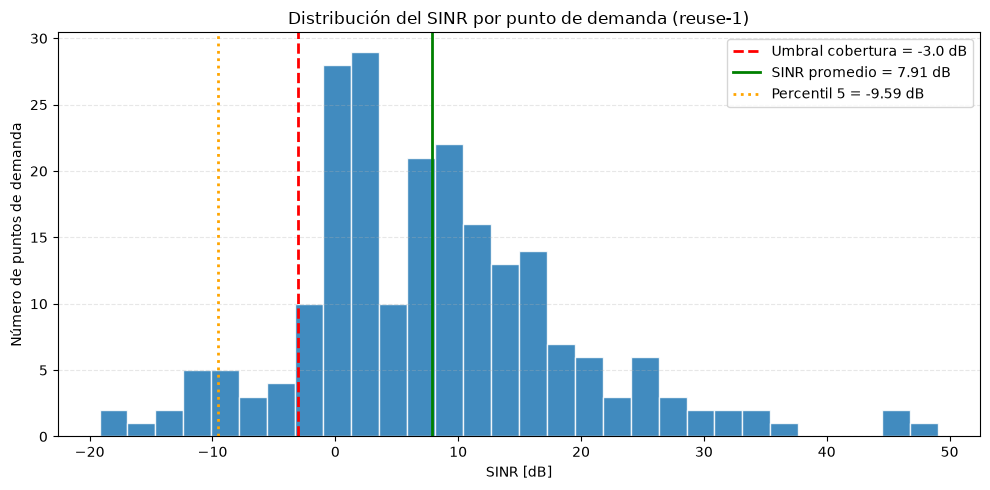

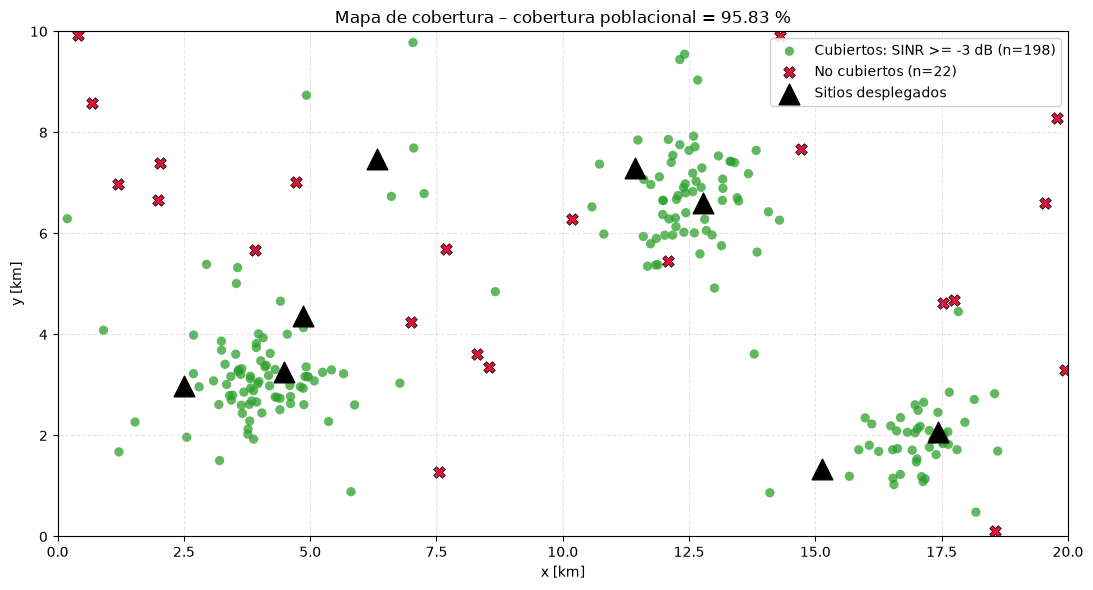

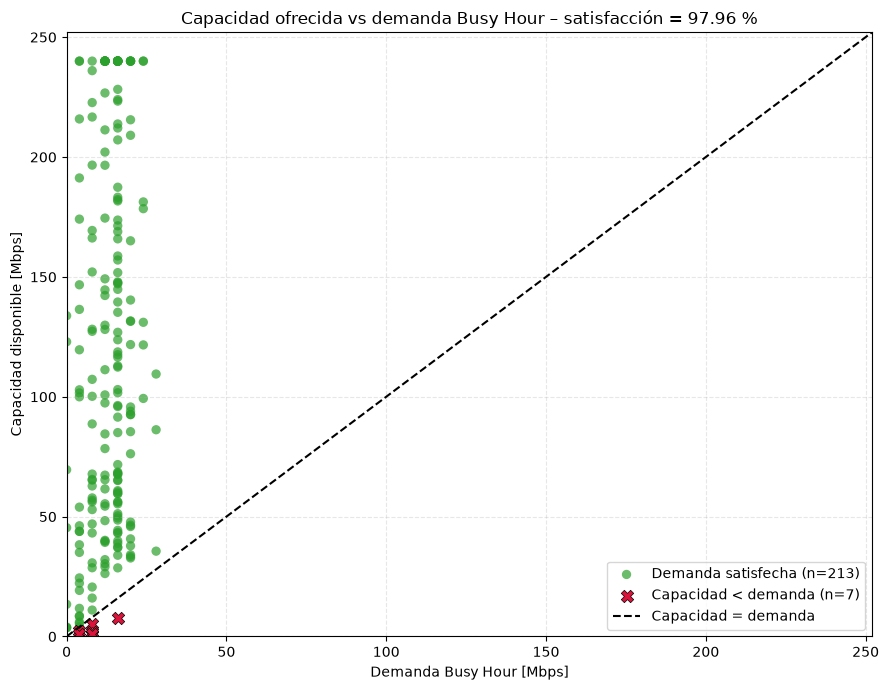

PB25 — Puntos con capacidad insuficiente


,demand_point,households,sinr_db,se_bphz,cap_mbps,demand_mbps,deficit_mbps
0,116,15,-8.470938,0.191818,7.672720,16.0,8.327280
2,183,7,-19.195044,0.017261,0.690446,8.0,7.309554
5,206,7,-18.240066,0.021475,0.858997,8.0,7.141003
3,190,6,-14.641828,0.048712,1.948495,8.0,6.051505
6,208,4,-16.755933,0.030133,1.205308,4.0,2.794692
1,171,6,-10.114977,0.134073,5.362911,8.0,2.637089
4,192,4,-14.206661,0.053752,2.150071,4.0,1.849929


In [34]:
# ============================================================
# PB25 — Visualizaciones técnicas de SINR, cobertura y capacidad
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# GRÁFICA 1 — Distribución del SINR
# ------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(10, 5))

ax1.hist(sinr_db_s2, bins=30, color="tab:blue", edgecolor="white", alpha=0.85)

ax1.axvline(coverage_threshold_db_s2, color="red", linestyle="--", linewidth=2,
            label=f"Umbral cobertura = {coverage_threshold_db_s2:.1f} dB")
ax1.axvline(metrics_sprint2["avg_sinr_db"], color="green", linestyle="-", linewidth=2,
            label=f"SINR promedio = {metrics_sprint2['avg_sinr_db']:.2f} dB")
ax1.axvline(metrics_sprint2["p05_sinr_db"], color="orange", linestyle=":", linewidth=2,
            label=f"Percentil 5 = {metrics_sprint2['p05_sinr_db']:.2f} dB")

ax1.set_title("Distribución del SINR por punto de demanda (reuse-1)")
ax1.set_xlabel("SINR [dB]")
ax1.set_ylabel("Número de puntos de demanda")
ax1.grid(True, alpha=0.3, linestyle="--", axis="y")
ax1.legend()

fig1.tight_layout()
fig1.savefig(RESULTS_DIR / "pb25_1_histograma_sinr.png", dpi=150)
plt.show()

# ------------------------------------------------------------
# GRÁFICA 2 — Mapa de cobertura
# ------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(12, 6))

ax2.scatter(
    demand.loc[coverage_mask_s2, "x_km"], demand.loc[coverage_mask_s2, "y_km"],
    c="tab:green", s=45, alpha=0.75, edgecolors="none",
    label=f"Cubiertos: SINR >= {coverage_threshold_db_s2:.0f} dB (n={int(coverage_mask_s2.sum())})",
)
ax2.scatter(
    demand.loc[~coverage_mask_s2, "x_km"], demand.loc[~coverage_mask_s2, "y_km"],
    c="crimson", s=70, marker="X", edgecolors="black", linewidths=0.5,
    label=f"No cubiertos (n={int((~coverage_mask_s2).sum())})",
)
ax2.scatter(
    sites.loc[selected_sites_s2, "x_km"], sites.loc[selected_sites_s2, "y_km"],
    marker="^", s=220, c="black", zorder=5, label="Sitios desplegados",
)

ax2.set_title(
    f"Mapa de cobertura – cobertura poblacional = "
    f"{metrics_sprint2['pop_covered_frac']*100:.2f} %"
)
ax2.set_xlabel("x [km]")
ax2.set_ylabel("y [km]")
ax2.set_xlim(0, params["area"]["width_km"])
ax2.set_ylim(0, params["area"]["height_km"])
ax2.set_aspect("equal", adjustable="box")
ax2.grid(True, alpha=0.3, linestyle="--")
ax2.legend(loc="upper right", framealpha=0.9)

fig2.tight_layout()
fig2.savefig(RESULTS_DIR / "pb25_2_mapa_cobertura.png", dpi=150)
plt.show()

# ------------------------------------------------------------
# GRÁFICA 3 — Capacidad vs demanda Busy Hour
# ------------------------------------------------------------
cap_mbps_pb25 = cap_bps_s2 / 1e6
dem_mbps_pb25 = demand_bps_s2 / 1e6

fig3, ax3 = plt.subplots(figsize=(9, 7))

ax3.scatter(
    dem_mbps_pb25[satisfied_mask_s2], cap_mbps_pb25[satisfied_mask_s2],
    c="tab:green", s=45, alpha=0.7, edgecolors="none",
    label=f"Demanda satisfecha (n={int(satisfied_mask_s2.sum())})",
)
ax3.scatter(
    dem_mbps_pb25[~satisfied_mask_s2], cap_mbps_pb25[~satisfied_mask_s2],
    c="crimson", s=80, marker="X", edgecolors="black", linewidths=0.5,
    label=f"Capacidad < demanda (n={int((~satisfied_mask_s2).sum())})",
)

lim_pb25 = max(dem_mbps_pb25.max(), cap_mbps_pb25.max()) * 1.05
ax3.plot([0, lim_pb25], [0, lim_pb25], "k--", linewidth=1.5,
         label="Capacidad = demanda")

ax3.set_title(
    f"Capacidad ofrecida vs demanda Busy Hour – "
    f"satisfacción = {metrics_sprint2['capacity_satisfied_frac']*100:.2f} %"
)
ax3.set_xlabel("Demanda Busy Hour [Mbps]")
ax3.set_ylabel("Capacidad disponible [Mbps]")
ax3.set_xlim(0, lim_pb25)
ax3.set_ylim(0, lim_pb25)
ax3.grid(True, alpha=0.3, linestyle="--")
ax3.legend(loc="lower right")

fig3.tight_layout()
fig3.savefig(RESULTS_DIR / "pb25_3_capacidad_vs_demanda.png", dpi=150)
plt.show()

# ------------------------------------------------------------
# Tabla de apoyo: puntos con déficit de capacidad
# ------------------------------------------------------------
deficit_pb25 = np.where(~satisfied_mask_s2)[0]

deficit_table_pb25 = pd.DataFrame({
    "demand_point": deficit_pb25,
    "households": demand.loc[deficit_pb25, "households"].to_numpy(),
    "sinr_db": sinr_db_s2[deficit_pb25],
    "se_bphz": se_bphz_s2[deficit_pb25],
    "cap_mbps": cap_mbps_pb25[deficit_pb25],
    "demand_mbps": dem_mbps_pb25[deficit_pb25],
    "deficit_mbps": dem_mbps_pb25[deficit_pb25] - cap_mbps_pb25[deficit_pb25],
}).sort_values("deficit_mbps", ascending=False)

print("PB25 — Puntos con capacidad insuficiente")
deficit_table_pb25

## Funcion Definitiva

In [35]:
# ============================================================
# FUNCIÓN FINAL DE EVALUACIÓN — MODELO TÉCNICO SPRINT 2
# ============================================================

def evaluate_plan_sprint2(selected_sites, reuse1=True):
    """
    Evalúa un conjunto de sitios utilizando el modelo técnico
    validado durante el Sprint 2.

    Incluye:
    - Asociación por mejor RSRP
    - Interferencia frequency reuse-1
    - Ruido térmico
    - SINR
    - Eficiencia espectral
    - Capacidad
    - Demanda Busy Hour
    - Cobertura según umbral mínimo de SINR
    - Satisfacción de capacidad

    Parámetros
    ----------
    selected_sites : lista
        Índices de los sitios candidatos desplegados.

    reuse1 : bool
        Si es True, los demás sitios desplegados generan
        interferencia sobre cada punto de demanda.

    Retorna
    -------
    metrics : dict
        Métricas técnicas del plan evaluado.
    """

    sel = np.array(selected_sites, dtype=int)

    # --------------------------------------------------------
    # Validaciones de entrada
    # --------------------------------------------------------

    if len(sel) == 0:
        return None

    if len(np.unique(sel)) != len(sel):
        raise ValueError("selected_sites contiene sitios repetidos.")

    if np.any(sel < 0) or np.any(sel >= len(sites)):
        raise ValueError("Existe un índice de sitio fuera del rango válido.")

    if len(sel) > params["planning"]["max_sites_to_deploy"]:
        raise ValueError(
            "El número de sitios supera max_sites_to_deploy."
        )


    # --------------------------------------------------------
    # 1. Asociación por mejor RSRP
    # --------------------------------------------------------

    rsrp_sel = rsrp_dbm[:, sel]

    best_local = np.argmax(
        rsrp_sel,
        axis=1
    )

    pr_serv_dbm = rsrp_sel[
        np.arange(len(demand)),
        best_local
    ]

    pr_serv_w = dbm_to_w(pr_serv_dbm)


    # --------------------------------------------------------
    # 2. Interferencia reuse-1
    # --------------------------------------------------------

    if reuse1 and len(sel) > 1:

        pr_all_w = dbm_to_w(rsrp_sel)

        interf_w = (
            pr_all_w.sum(axis=1)
            - pr_serv_w
        )

    else:

        interf_w = np.zeros_like(
            pr_serv_w
        )


    # --------------------------------------------------------
    # 3. SINR
    # --------------------------------------------------------

    sinr_linear = (
        pr_serv_w
        / (interf_w + noise_w)
    )

    sinr_db = (
        10
        * np.log10(
            sinr_linear + 1e-12
        )
    )


    # --------------------------------------------------------
    # 4. Eficiencia espectral
    # --------------------------------------------------------

    se_bphz = np.log2(
        1 + sinr_linear
    )

    se_bphz = np.minimum(
        se_bphz,
        SE_CAP
    )


    # --------------------------------------------------------
    # 5. Capacidad
    # --------------------------------------------------------

    cap_bps = (
        BW_HZ
        * se_bphz
    )


    # --------------------------------------------------------
    # 6. Demanda Busy Hour
    # --------------------------------------------------------

    subscribers = (
        demand["subscribers_initial"]
        .to_numpy()
    )

    concurrency = (
        params["demand"]["busy_hour_concurrency"]
    )

    target_mbps = (
        params["demand"]
        ["target_throughput_mbps_per_subscriber"]
    )

    demand_bps = (
        subscribers
        * concurrency
        * target_mbps
        * 1e6
    )


    # --------------------------------------------------------
    # 7. Cobertura formal por SINR
    # --------------------------------------------------------

    coverage_threshold_db = (
        params["radio"]
        ["sinr_thresholds_db"]
        ["coverage_min_sinr_db"]
    )

    coverage_mask = (
        sinr_db
        >= coverage_threshold_db
    )


    # --------------------------------------------------------
    # 8. Satisfacción de capacidad
    # --------------------------------------------------------

    satisfied_mask = (
        cap_bps
        >= demand_bps
    )


    # --------------------------------------------------------
    # 9. Métricas ponderadas por hogares
    # --------------------------------------------------------

    households = (
        demand["households"]
        .to_numpy()
    )

    total_households = (
        households.sum()
    )

    pop_covered_frac = float(
        (
            households
            * coverage_mask
        ).sum()
        / total_households
    )

    capacity_satisfied_frac = float(
        (
            households
            * satisfied_mask
        ).sum()
        / total_households
    )


    # --------------------------------------------------------
    # 10. Métricas finales
    # --------------------------------------------------------

    metrics = {
        "sites_deployed": int(len(sel)),

        "pop_covered_frac":
            pop_covered_frac,

        "capacity_satisfied_frac":
            capacity_satisfied_frac,

        "avg_sinr_db":
            float(np.mean(sinr_db)),

        "p05_sinr_db":
            float(np.quantile(
                sinr_db,
                0.05
            )),

        "avg_se_bphz":
            float(np.mean(se_bphz)),
    }

    return metrics


# ============================================================
# VALIDACIÓN DE LA FUNCIÓN FINAL
# ============================================================

metrics_function_s2 = evaluate_plan_sprint2(
    selected_sites_s2
)

# Debe reproducir exactamente las métricas integradas en PB22
for metric in metrics_sprint2:

    assert np.isclose(
        metrics_function_s2[metric],
        metrics_sprint2[metric]
    ), f"No coincide la métrica: {metric}"

print("evaluate_plan_sprint2() validada correctamente.")
print()

for metric, value in metrics_function_s2.items():
    print(f"{metric:>26}: {value}")

evaluate_plan_sprint2() validada correctamente.

            sites_deployed: 8
          pop_covered_frac: 0.9583333333333334
   capacity_satisfied_frac: 0.9795833333333334
               avg_sinr_db: 7.907271919742439
               p05_sinr_db: -9.585938922523141
               avg_se_bphz: 2.8853867959210295


# SPRINT 3 — PRIMERA OPTIMIZACIÓN: ITERATED LOCAL SEARCH (ILS)

## Objetivo del Sprint 3

En este sprint se desarrolla la primera estrategia de optimización propia del equipo para la selección de sitios de la red 5G FWA.

Como punto de partida se utiliza el modelo técnico validado durante el Sprint 2 mediante `evaluate_plan_sprint2()`.

El algoritmo seleccionado es **Iterated Local Search (ILS)** o **Búsqueda Local Iterada**.

La estrategia extiende la búsqueda local incluida en el escenario base. Mientras la búsqueda local convencional puede quedar atrapada en un óptimo local, ILS introduce perturbaciones controladas sobre la solución encontrada y ejecuta nuevamente la búsqueda local desde la nueva región del espacio de soluciones.

La estructura utilizada será:

**Solución inicial → Búsqueda local → Perturbación → Búsqueda local → Comparación → Repetición**


## Optimización con Iterated Local Search (PB27–PB29)

In [36]:
# ============================================================
# SPRINT 3 — PB27, PB28 Y PB29
# Función objetivo + pesos + Algoritmo 1: Iterated Local Search
# ============================================================

# ------------------------------------------------------------
# PB27 - PB28: FUNCIÓN OBJETIVO Y PESOS
# ------------------------------------------------------------

W_COV = 1.0       # Importancia de la cobertura poblacional
W_CAP = 1.0       # Importancia de la capacidad satisfecha
W_SITES = 0.15    # Penalización por número de sitios

MAX_SITES = params["planning"]["max_sites_to_deploy"]


def objective_sprint3(metrics):
    """
    Función objetivo del Sprint 3.

    Maximiza cobertura y capacidad satisfecha,
    penalizando el número de sitios desplegados.
    """

    return (
        W_COV * metrics["pop_covered_frac"]
        + W_CAP * metrics["capacity_satisfied_frac"]
        - W_SITES * (metrics["sites_deployed"] / MAX_SITES)
    )


# ------------------------------------------------------------
# PB29: BÚSQUEDA LOCAL 1-SWAP
# ------------------------------------------------------------

def local_search_1swap(initial_sites):
    """
    Mejora una solución explorando intercambios 1-swap:
    sale un sitio desplegado y entra uno no desplegado.

    En cada iteración se selecciona el mejor vecino posible.
    El proceso termina cuando ningún vecino mejora J.
    """

    current = sorted(map(int, initial_sites))
    current_metrics = evaluate_plan_sprint2(current)
    current_J = objective_sprint3(current_metrics)

    all_sites = set(range(len(sites)))

    while True:

        selected = set(current)
        not_selected = sorted(all_sites - selected)

        best_neighbor = None
        best_metrics = None
        best_J = current_J

        # Explorar todo el vecindario 1-swap
        for site_out in current:

            for site_in in not_selected:

                candidate = sorted(
                    (selected - {site_out}) | {site_in}
                )

                metrics = evaluate_plan_sprint2(candidate)
                J = objective_sprint3(metrics)

                if J > best_J:
                    best_neighbor = candidate
                    best_metrics = metrics
                    best_J = J

        # Si ningún vecino mejora, llegamos a un óptimo local
        if best_neighbor is None:
            break

        current = best_neighbor
        current_metrics = best_metrics
        current_J = best_J

    return current, current_metrics, current_J


# ------------------------------------------------------------
# PERTURBACIÓN 2-SWAP
# ------------------------------------------------------------

def perturb_2swap(solution, rng):
    """
    Perturbación del ILS:
    retira dos sitios desplegados y agrega dos diferentes.
    """

    solution = sorted(map(int, solution))

    selected = np.array(solution, dtype=int)

    not_selected = np.array(
        sorted(set(range(len(sites))) - set(solution)),
        dtype=int
    )

    sites_out = set(
        map(
            int,
            rng.choice(selected, size=2, replace=False)
        )
    )

    sites_in = set(
        map(
            int,
            rng.choice(not_selected, size=2, replace=False)
        )
    )

    return sorted(
        (set(solution) - sites_out) | sites_in
    )


# ------------------------------------------------------------
# ITERATED LOCAL SEARCH (ILS)
# ------------------------------------------------------------

def iterated_local_search(
    S=8,
    iterations=20,
    seed=42
):
    """
    Algoritmo 1 del Sprint 3.

    1. Parte de solucion aleatoria.
    2. Aplica búsqueda local 1-swap.
    3. Perturba la solución mediante 2-swap.
    4. Aplica nuevamente búsqueda local.
    5. Conserva la mejor solución encontrada.
    """

    rng = np.random.default_rng(seed)

    # Solución inicial aleatoria reproducible
    initial = sorted(
        rng.choice(
            len(sites),
            size=S,
            replace=False
        ).tolist()
    )

    # Primer óptimo local
    current, current_metrics, current_J = local_search_1swap(
        initial
    )

    best = current.copy()
    best_metrics = current_metrics.copy()
    best_J = current_J

    # Búsqueda local iterada
    for _ in range(iterations):

        # Perturbación para salir del óptimo local actual
        perturbed = perturb_2swap(current, rng)

        # Nueva búsqueda local
        candidate, candidate_metrics, candidate_J = (
            local_search_1swap(perturbed)
        )

        # Se acepta solamente si mejora la solución actual
        if candidate_J > current_J:

            current = candidate
            current_metrics = candidate_metrics
            current_J = candidate_J

        # Mejor solución global encontrada
        if candidate_J > best_J:

            best = candidate.copy()
            best_metrics = candidate_metrics.copy()
            best_J = candidate_J

    return best, best_metrics, best_J


# ============================================================
# PRUEBA DEL ALGORITMO
# ============================================================

# Referencia obtenida al finalizar Sprint 2
reference_sites = selected_sites_s2
reference_metrics = evaluate_plan_sprint2(reference_sites)
reference_J = objective_sprint3(reference_metrics)

# Ejecutar ILS
ils_sites, ils_metrics, ils_J = iterated_local_search(
    S=8,
    iterations=20,
    seed=42
)


# ------------------------------------------------------------
# RESULTADOS
# ------------------------------------------------------------

print("FUNCIÓN OBJETIVO")
print("----------------")
print(
    f"J = {W_COV}·Cobertura "
    f"+ {W_CAP}·Capacidad "
    f"- {W_SITES}·(S/{MAX_SITES})"
)

print()
print("Pesos seleccionados:")
print(f"w_cov   = {W_COV}")
print(f"w_cap   = {W_CAP}")
print(f"w_sites = {W_SITES}")

print()
print(
    "Penalización por cada sitio adicional:",
    round(W_SITES / MAX_SITES, 4)
)


comparison_s3 = pd.DataFrame([
    {
        "Solución": "Referencia Sprint 2",
        "Sitios": reference_sites,
        "S": reference_metrics["sites_deployed"],
        "Cobertura": reference_metrics["pop_covered_frac"],
        "Capacidad": reference_metrics["capacity_satisfied_frac"],
        "SINR medio": reference_metrics["avg_sinr_db"],
        "SINR p05": reference_metrics["p05_sinr_db"],
        "SE media": reference_metrics["avg_se_bphz"],
        "J": reference_J
    },
    {
        "Solución": "ILS Sprint 3",
        "Sitios": ils_sites,
        "S": ils_metrics["sites_deployed"],
        "Cobertura": ils_metrics["pop_covered_frac"],
        "Capacidad": ils_metrics["capacity_satisfied_frac"],
        "SINR medio": ils_metrics["avg_sinr_db"],
        "SINR p05": ils_metrics["p05_sinr_db"],
        "SE media": ils_metrics["avg_se_bphz"],
        "J": ils_J
    }
])

print()
print("PRUEBA DEL ALGORITMO 1")
print("----------------------")

display(comparison_s3)


# ------------------------------------------------------------
# VALIDACIONES BÁSICAS
# ------------------------------------------------------------

assert len(ils_sites) == 8
assert len(set(ils_sites)) == 8
assert all(0 <= site < len(sites) for site in ils_sites)
assert ils_metrics["sites_deployed"] <= MAX_SITES
assert np.isfinite(ils_J)

print()
print("Validaciones del ILS: OK")

FUNCIÓN OBJETIVO
----------------
J = 1.0·Cobertura + 1.0·Capacidad - 0.15·(S/12)

Pesos seleccionados:
w_cov   = 1.0
w_cap   = 1.0
w_sites = 0.15

Penalización por cada sitio adicional: 0.0125

PRUEBA DEL ALGORITMO 1
----------------------


,Solución,Sitios,S,Cobertura,Capacidad,SINR medio,SINR p05,SE media,J
0,Referencia Sprint 2,"[0, 3, 6, 7, 11, 12, 13, 16]",8,0.958333,0.979583,7.907272,-9.585939,2.885387,1.837917
1,ILS Sprint 3,"[0, 2, 6, 7, 10, 13, 15, 35]",8,0.956667,0.984167,7.636665,-5.959592,2.773840,1.840833



Validaciones del ILS: OK


## Evaluación comparativa del ILS (PB30, PB31 y PB34)

In [37]:
# ============================================================
# SPRINT 3 — Jhon
# PB30 + PB31 + PB34
# ============================================================

# PB30 — Ejecutar el algoritmo para diferentes valores de S
#
# Usar la función del algoritmo ILS implementada en PB29.
# Ejecutar el algoritmo para diferentes cantidades de sitios
# desplegados, respetando siempre S <= 12.
#
# Para cada valor de S guardar como mínimo:
# - sitios seleccionados
# - pop_covered_frac
# - capacity_satisfied_frac
# - avg_sinr_db
# - p05_sinr_db
# - avg_se_bphz
# - valor de la función objetivo J
#
# IMPORTANTE:
# No modificar evaluate_plan_sprint2(), objective_sprint3()
# ni las funciones del ILS. Esta sección únicamente debe
# consumir las funciones ya implementadas.


# PB31 — Comparar los resultados contra el baseline
#
# Tomar los resultados obtenidos con ILS y compararlos con
# la solución de referencia obtenida anteriormente.
#
# La comparación debe permitir observar, como mínimo:
# - número de sitios
# - cobertura poblacional
# - fracción de capacidad satisfecha
# - SINR promedio
# - SINR p05
# - eficiencia espectral promedio
# - función objetivo J
#
# Identificar cuáles configuraciones cumplen simultáneamente
# los umbrales mínimos del curso:
# cobertura >= 0.85
# capacidad satisfecha >= 0.80


# PB34 — Cuantificar la mejora obtenida
#
# A partir de la comparación anterior, calcular de forma
# cuantitativa cuánto mejora o empeora ILS respecto a la
# solución de referencia.
#
# Reportar las diferencias en:
# - cantidad de sitios
# - cobertura
# - capacidad satisfecha
# - SINR promedio
# - SINR p05
# - eficiencia espectral
# - función objetivo J
#
# Al final dejar claramente identificada la mejor solución
# encontrada y explicar brevemente por qué se considera mejor.

## Análisis de trade-offs y visualización (PB32, PB33 y PB36)

In [38]:
# ============================================================
# SPRINT 3 — Emanuel
# PB32 + PB33 + PB36
# ============================================================

# PB32 — Analizar trade-off cobertura vs capacidad
#
# Utilizar los resultados obtenidos para los diferentes
# valores de S en PB30.
#
# Analizar cómo cambia:
# - pop_covered_frac
# - capacity_satisfied_frac
#
# a medida que aumenta el número de sitios.
#
# Identificar situaciones donde aumentar S mejore una métrica
# pero produzca poco beneficio, ningún beneficio o deterioro
# en la otra.
#
# Identificar también a partir de qué número de sitios se
# cumplen simultáneamente los umbrales mínimos del curso.


# PB33 — Analizar calidad/interferencia vs número de sitios
#
# Usando las mismas ejecuciones de PB30, estudiar cómo cambian:
# - avg_sinr_db
# - p05_sinr_db
# - avg_se_bphz
#
# con el número de sitios desplegados.
#
# Relacionar los resultados con el modelo frequency reuse 1:
# agregar sitios puede mejorar cobertura/capacidad, pero también
# puede incrementar la interferencia recibida desde otros sitios.
#
# El análisis debe basarse en los resultados realmente obtenidos;
# no asumir de antemano que una métrica necesariamente aumenta
# o disminuye.


# PB36 — Crear tablas y gráficas comparativas
#
# Construir visualizaciones claras a partir de los resultados
# anteriores.
#
# Como mínimo deben permitir observar:
# - cobertura y capacidad vs número de sitios
# - calidad de radio (SINR) vs número de sitios
# - comportamiento de la función objetivo J
#
# Incluir una tabla resumen con las configuraciones más
# relevantes, especialmente:
# - solución de referencia
# - menor S que cumple los umbrales
# - mejor solución encontrada por ILS
#
# Las gráficas deben tener título, nombres de ejes, unidades
# cuando correspondan y leyenda.
#
# IMPORTANTE:
# No modificar el modelo técnico ni el algoritmo ILS.
# Esta sección únicamente analiza y visualiza resultados.